## 18.8) Base Plano de Saúde

# Regressão Com Random Forest

In [25]:
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [26]:
base_plano_saude2 = pd.read_csv('plano_saude2.csv')
base_plano_saude2

,idade,custo
0,18,470
1,23,520
2,28,630
3,33,830
4,38,1150
5,43,1530
6,48,2040
7,53,3080
8,58,5100
9,63,10100


In [27]:
X_plano_saude2 = base_plano_saude2.iloc[:, 0:1].values #o x recebe os dados da idade
y_plano_saude2 = base_plano_saude2.iloc[:, 1].values # o y que desejamos prever é o do custo

In [28]:
X_plano_saude2 # atributo preditor, que é a idade.

array([[18],
       [23],
       [28],
       [33],
       [38],
       [43],
       [48],
       [53],
       [58],
       [63]])

In [29]:
y_plano_saude2 # respectivos preços. Regressão polinomial, elevados ao quadrado

array([  470,   520,   630,   830,  1150,  1530,  2040,  3080,  5100,
       10100])

## Ideia é fazer a previsão do custo do plano de saúde

In [30]:
# import o random forest
from sklearn.ensemble import RandomForestRegressor

# instanciar o objeto dessa classe
# número de árvores n_estimators
regressor_random_forest_saude = RandomForestRegressor(n_estimators = 10)
# fazer o treinamento com o fit.
regressor_random_forest_saude.fit(X_plano_saude2, y_plano_saude2)




RandomForestRegressor(n_estimators=10)

In [31]:
regressor_random_forest_saude.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 10,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [32]:
# geração da árvore

In [33]:
regressor_random_forest_saude.score(X_plano_saude2, y_plano_saude2)

0.9791135311502254

In [34]:
qualidade_algoritmo = regressor_random_forest_saude.score(X_plano_saude2, y_plano_saude2)

print('A acurácia do modelo Random Forest com regressão é de {:.0f}%.'.format(qualidade_algoritmo*100)) 
# quanto mais perto de 1, melhor é esse valor.

A acurácia do modelo Random Forest com regressão é de 98%.


In [35]:
X_plano_saude2

array([[18],
       [23],
       [28],
       [33],
       [38],
       [43],
       [48],
       [53],
       [58],
       [63]])

In [36]:
# buscando a idade mínima e máxima na base de dados, e colocando um encremento de 0,1 em 0,1
# dados de 18 até 63 anos de idade, todos os números de 0,1 a 0,1. 
X_teste_arvore = np.arange(min(X_plano_saude2), max(X_plano_saude2), 0.1)
X_teste_arvore

/tmp/ipykernel_11312/80561598.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_teste_arvore = np.arange(min(X_plano_saude2), max(X_plano_saude2), 0.1)


array([18. , 18.1, 18.2, 18.3, 18.4, 18.5, 18.6, 18.7, 18.8, 18.9, 19. ,
       19.1, 19.2, 19.3, 19.4, 19.5, 19.6, 19.7, 19.8, 19.9, 20. , 20.1,
       20.2, 20.3, 20.4, 20.5, 20.6, 20.7, 20.8, 20.9, 21. , 21.1, 21.2,
       21.3, 21.4, 21.5, 21.6, 21.7, 21.8, 21.9, 22. , 22.1, 22.2, 22.3,
       22.4, 22.5, 22.6, 22.7, 22.8, 22.9, 23. , 23.1, 23.2, 23.3, 23.4,
       23.5, 23.6, 23.7, 23.8, 23.9, 24. , 24.1, 24.2, 24.3, 24.4, 24.5,
       24.6, 24.7, 24.8, 24.9, 25. , 25.1, 25.2, 25.3, 25.4, 25.5, 25.6,
       25.7, 25.8, 25.9, 26. , 26.1, 26.2, 26.3, 26.4, 26.5, 26.6, 26.7,
       26.8, 26.9, 27. , 27.1, 27.2, 27.3, 27.4, 27.5, 27.6, 27.7, 27.8,
       27.9, 28. , 28.1, 28.2, 28.3, 28.4, 28.5, 28.6, 28.7, 28.8, 28.9,
       29. , 29.1, 29.2, 29.3, 29.4, 29.5, 29.6, 29.7, 29.8, 29.9, 30. ,
       30.1, 30.2, 30.3, 30.4, 30.5, 30.6, 30.7, 30.8, 30.9, 31. , 31.1,
       31.2, 31.3, 31.4, 31.5, 31.6, 31.7, 31.8, 31.9, 32. , 32.1, 32.2,
       32.3, 32.4, 32.5, 32.6, 32.7, 32.8, 32.9, 33

In [37]:

# previsão do plano de saúde para todas as idades.
X_teste_arvore.shape #450 dados de idade
# colocar no formato de matriz
X_teste_arvore = X_teste_arvore.reshape(-1,1)
X_teste_arvore.shape # 450 linhas e 1 coluna

(450, 1)

In [41]:
# sequência de várias idades, idade mínima a máxima, com incremento de 0,1 a 0,1.
X_teste_arvore

array([[18. ],
       [18.1],
       [18.2],
       [18.3],
       [18.4],
       [18.5],
       [18.6],
       [18.7],
       [18.8],
       [18.9],
       [19. ],
       [19.1],
       [19.2],
       [19.3],
       [19.4],
       [19.5],
       [19.6],
       [19.7],
       [19.8],
       [19.9],
       [20. ],
       [20.1],
       [20.2],
       [20.3],
       [20.4],
       [20.5],
       [20.6],
       [20.7],
       [20.8],
       [20.9],
       [21. ],
       [21.1],
       [21.2],
       [21.3],
       [21.4],
       [21.5],
       [21.6],
       [21.7],
       [21.8],
       [21.9],
       [22. ],
       [22.1],
       [22.2],
       [22.3],
       [22.4],
       [22.5],
       [22.6],
       [22.7],
       [22.8],
       [22.9],
       [23. ],
       [23.1],
       [23.2],
       [23.3],
       [23.4],
       [23.5],
       [23.6],
       [23.7],
       [23.8],
       [23.9],
       [24. ],
       [24.1],
       [24.2],
       [24.3],
       [24.4],
       [24.5],
       [24

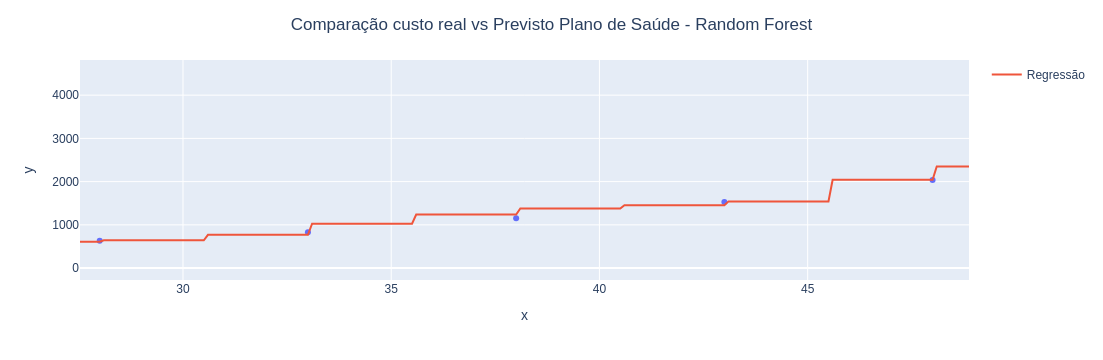

In [42]:
grafico = px.scatter(x = X_plano_saude2.ravel(), y = y_plano_saude2)
grafico.add_scatter(x = X_teste_arvore.ravel(), y = regressor_random_forest_saude.predict(X_teste_arvore), name = 'Regressão')
grafico.update_layout(
        title=f'Comparação custo real vs Previsto Plano de Saúde - Random Forest',
        title_x=0.5
    )

grafico.show()
grafico.write_html(f"Grafico_randomforest_regressao_planosaude_4.html")

In [43]:

# vamos simular uma pessoa de 40 anos, e saber o quanto ela pagaria. 

regressor_random_forest_saude.predict([[40]])



array([1378.])

In [44]:
# no gráfico há mais geração de split. Olhando as linhas de 40 anos do eixo x e ver o custo em y

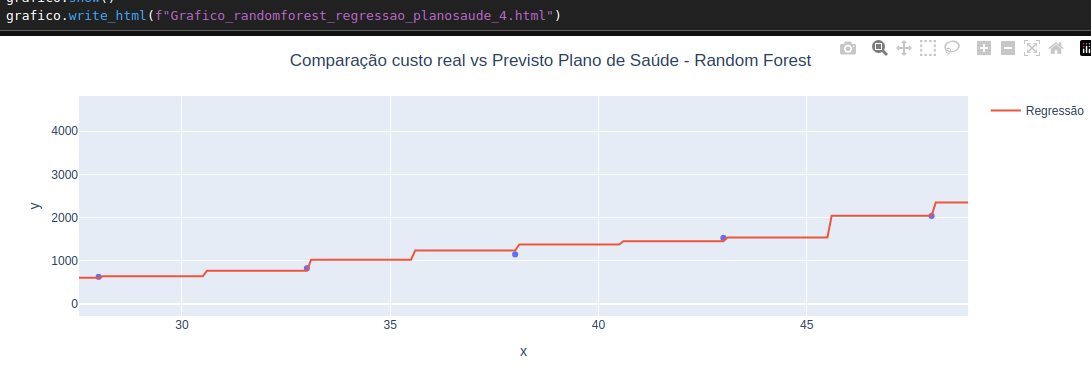

Regressão com Random Forest

Conjunto de árvores =» Random Forest (Floresta randômica)



Ensemble learning (aprendizagem em conjunto)

- "Consultar diversos profissionais para tomar uma decisão"

- Vários algoritmos juntos para construir um algoritmo mais "forte"

- Usa a média (regressão) ou votos da maioria (classificação) para dar a resposta final


previsão usando a média


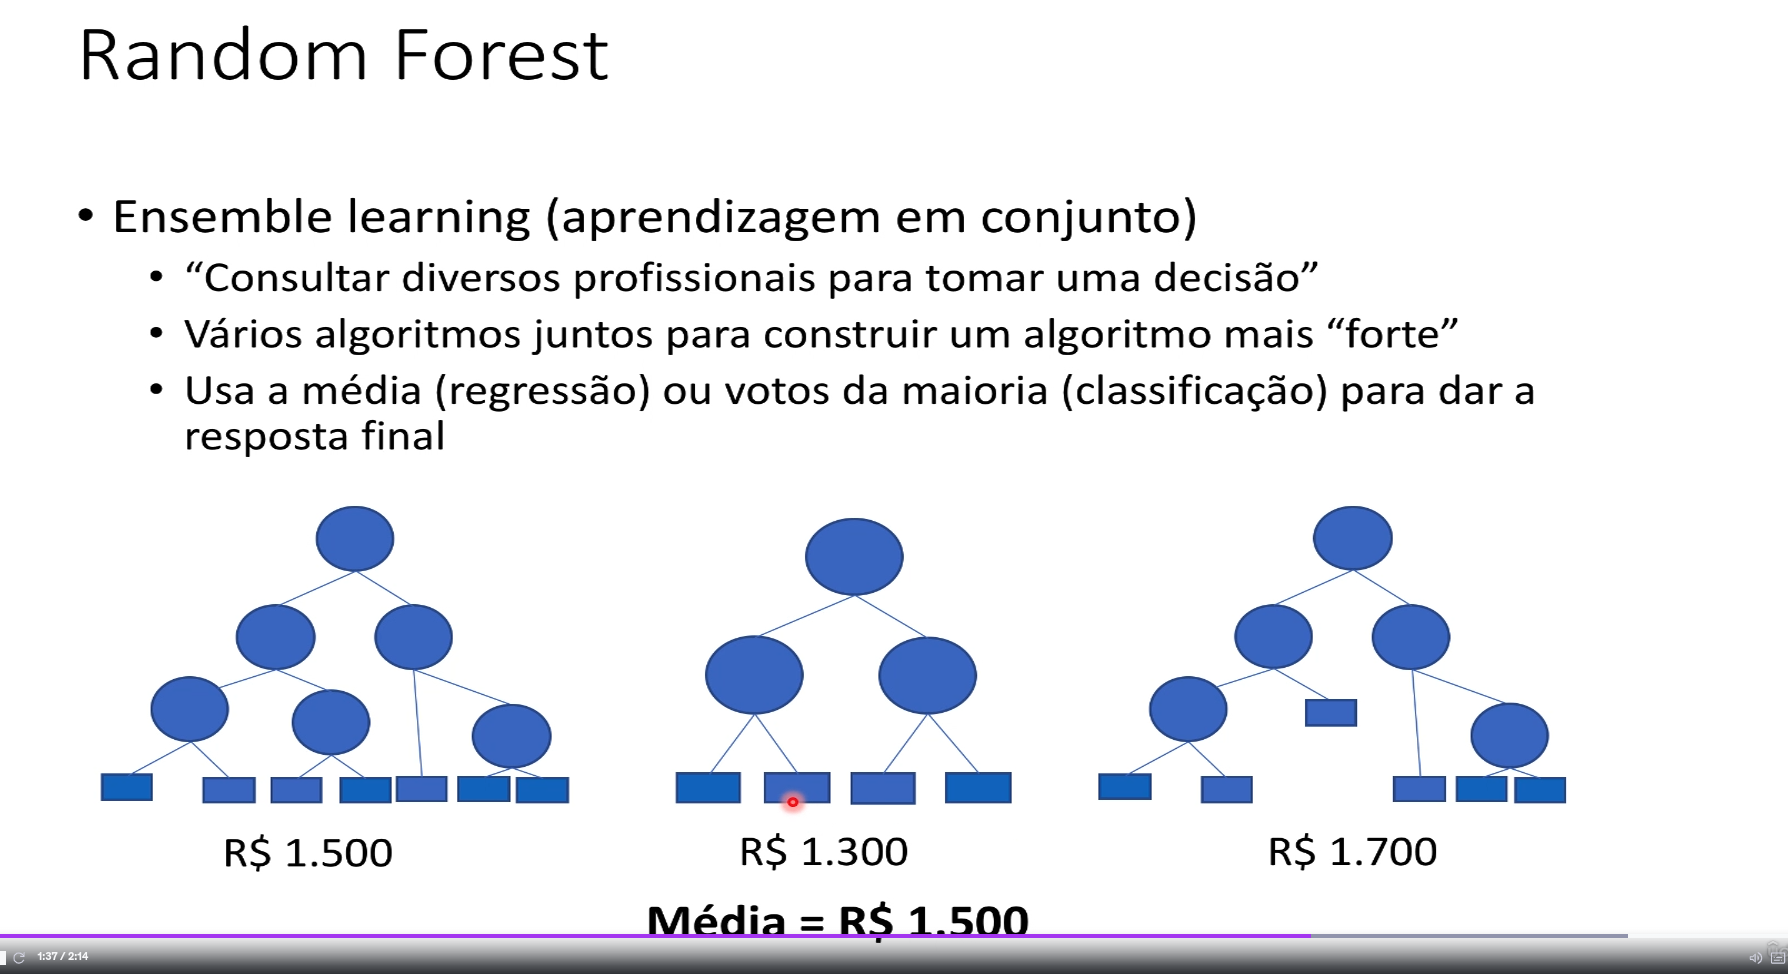